In [160]:
from source import *
import torch

# Load Image

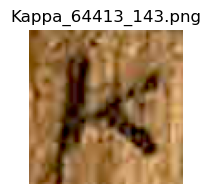

In [4]:
import pandas as pd

medchar = pd.read_csv('data/medchar.csv')

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import random
import os

image_folder = 'data/samples/palitchar' # can change to 'images/medchar' 
palit_images = [os.path.join(image_folder, f) for f in os.listdir(image_folder)]
random_image_path = random.choice(palit_images)
img = mpimg.imread(random_image_path)
plt.figure(figsize=(2, 2))
plt.imshow(img, cmap='gray') # Assuming grayscale images based on previous processing
plt.title(os.path.basename(random_image_path))
plt.axis('off') # Hide axes
plt.show()

# Preprocess Image

In [166]:
def preprocess_image_2d(image_path, size=(64, 64), otsu=False):
    img = Image.open(image_path).convert('L')  # Grayscale
    img_np = np.array(img)

    if otsu:
      _, img_np = cv2.threshold(img_np, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
      img_np = 255 - img_np

    # Resize to standard size
    img_resized = cv2.resize(img_np, size, interpolation=cv2.INTER_AREA)

    # Normalize pixel values to [0, 1]
    img_normalized = img_resized.astype(np.float32) / 255.0

    return img_normalized  # Return as 2D numpy array


image = preprocess_image_2d(random_image_path, otsu=False)

# Get the channel and batch dimension
image = torch.tensor(image).unsqueeze(0).unsqueeze(0)

In [183]:
labels = ['Alpha', 'Beta', 'Chi', 'Delta', 'Epsilon', 'Eta', 'Gamma', 'Iota', 'Kappa',
 'Lambda', 'Mu', 'Nu', 'Omega', 'Omicron', 'Phi', 'Pi', 'Psi', 'Rho', 'Sigma', 'Tau',
 'Theta', 'Upsilon', 'Xi', 'Zeta']

## Load the Model and perform inference

In [185]:
model = CNN2D(num_classes=24, image_size=(64, 64))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.load_state_dict(torch.load('best_cnn_letter_model.pth', map_location=torch.device(device)))

<All keys matched successfully>

In [187]:
output = model(image)
pred_class_index = torch.argmax(output, dim=1).item()
print("Predicted class:", labels[pred_class])

Predicted class: Kappa
